# 03 — Modeling

Train and compare classifiers on the processed bank-marketing splits to predict term-deposit subscription.


In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Load processed artifacts

Artifacts come from `02_preprocess.ipynb`. Path is relative to `notebooks/`.


In [2]:
# Local path from notebooks/. On Colab, point this at your project data/processed folder.
PROCESSED_DIR = Path("../data/processed")

X_train = np.load(PROCESSED_DIR / "X_train.npy")
X_val = np.load(PROCESSED_DIR / "X_val.npy")
X_test = np.load(PROCESSED_DIR / "X_test.npy")

y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_val = np.load(PROCESSED_DIR / "y_val.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

feature_names = joblib.load(PROCESSED_DIR / "feature_names.joblib")

pos_rate = float(y_train.mean())
scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Features:", len(feature_names))
print("Positive rate (train):", round(pos_rate, 3))
print("XGBoost scale_pos_weight:", round(scale_pos_weight, 2))


Training: (27126, 56) (27126,)
Validation: (9042, 56) (9042,)
Test: (9043, 56) (9043,)
Features: 56
Positive rate (train): 0.117
XGBoost scale_pos_weight: 7.55


## Metrics and cross-validation

The target is imbalanced (~12% yes), so we track ROC-AUC, PR-AUC, precision, recall, and F1 — not accuracy alone.


In [3]:
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "accuracy": "accuracy",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def evaluate_split(model, X, y, name):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, prob),
        "PR-AUC": average_precision_score(y, prob),
    }


def print_cv(results, title):
    print(title)
    for metric in scoring:
        values = results[f"test_{metric}"]
        print(f"{metric}: {values.mean():.3f} +/- {values.std():.3f}")


## Logistic Regression

Interpretable linear baseline with balanced class weights for the minority subscriber class.


In [4]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE,
)
lr_cv = cross_validate(lr, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
print_cv(lr_cv, "Logistic Regression CV (train)")

lr.fit(X_train, y_train)
lr_val = evaluate_split(lr, X_val, y_val, "Logistic Regression")
pd.DataFrame([lr_val]).round(3)


Logistic Regression CV (train)
roc_auc: 0.767 +/- 0.004
pr_auc: 0.398 +/- 0.007
precision: 0.276 +/- 0.009
recall: 0.625 +/- 0.008
f1: 0.383 +/- 0.008
accuracy: 0.764 +/- 0.009


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.765,0.279,0.639,0.388,0.778,0.42


## Random Forest

Bagging ensemble for nonlinear relationships; also uses balanced class weights.


In [5]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_cv = cross_validate(rf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
print_cv(rf_cv, "Random Forest CV (train)")

rf.fit(X_train, y_train)
rf_val = evaluate_split(rf, X_val, y_val, "Random Forest")
pd.DataFrame([rf_val]).round(3)


Random Forest CV (train)
roc_auc: 0.776 +/- 0.005
pr_auc: 0.410 +/- 0.011
precision: 0.621 +/- 0.033
recall: 0.194 +/- 0.005
f1: 0.296 +/- 0.009
accuracy: 0.892 +/- 0.002


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.894,0.624,0.228,0.334,0.789,0.433


## XGBoost

Boosting baseline for tabular data. `scale_pos_weight` ≈ negatives/positives so the model pays more attention to the rare subscriber class during training.


In [6]:
xgb = XGBClassifier(
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_cv = cross_validate(xgb, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
print_cv(xgb_cv, "XGBoost CV (train)")

xgb.fit(X_train, y_train)
xgb_val = evaluate_split(xgb, X_val, y_val, "XGBoost")
pd.DataFrame([xgb_val]).round(3)


XGBoost CV (train)
roc_auc: 0.749 +/- 0.009
pr_auc: 0.380 +/- 0.010
precision: 0.343 +/- 0.014
recall: 0.514 +/- 0.006
f1: 0.411 +/- 0.011
accuracy: 0.828 +/- 0.007


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.832,0.362,0.576,0.445,0.783,0.437


## Compare validation results

We choose a model using ranking metrics (ROC-AUC / PR-AUC) because those measure ordering quality before a threshold is locked in.


In [7]:
val_compare = pd.DataFrame([lr_val, rf_val, xgb_val]).round(3)
val_compare


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.765,0.279,0.639,0.388,0.778,0.420
1,Random Forest,0.894,0.624,0.228,0.334,0.789,0.433
2,XGBoost,0.832,0.362,0.576,0.445,0.783,0.437


**Why XGBoost despite logistic regression's higher recall?**  
LR with balanced weights predicts "yes" more often, so recall looks strong, but precision is much lower (many wasted calls). XGBoost leads ROC-AUC and PR-AUC, which means better ranking of likely subscribers. We can recover recall later by lowering the decision threshold, without giving up ranking quality.


## Validation curves


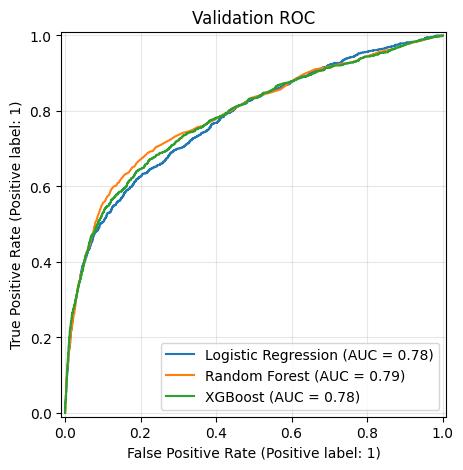

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(lr, X_val, y_val, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_estimator(rf, X_val, y_val, name="Random Forest", ax=ax)
RocCurveDisplay.from_estimator(xgb, X_val, y_val, name="XGBoost", ax=ax)
ax.set_title("Validation ROC")
ax.grid(alpha=0.3)
plt.show()


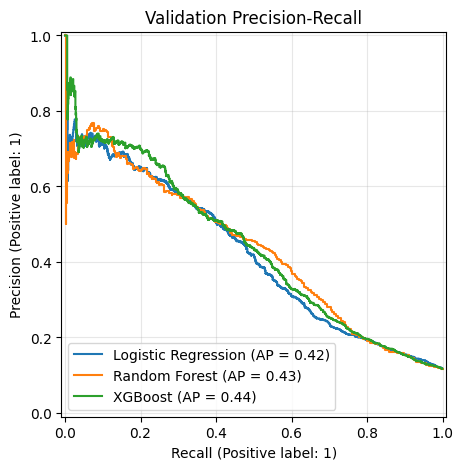

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_estimator(lr, X_val, y_val, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_estimator(rf, X_val, y_val, name="Random Forest", ax=ax)
PrecisionRecallDisplay.from_estimator(xgb, X_val, y_val, name="XGBoost", ax=ax)
ax.set_title("Validation Precision-Recall")
ax.grid(alpha=0.3)
plt.show()


## Tune XGBoost

Randomized search on the training set with stratified CV, optimizing PR-AUC. Keep `scale_pos_weight` fixed from the training class ratio.


In [10]:
xgb_parameters = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_lambda": [0.1, 1, 5, 10],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_distributions=xgb_parameters,
    n_iter=25,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print("Best parameters:", xgb_search.best_params_)
print("Best CV PR-AUC:", round(xgb_search.best_score_, 3))

tuned_val = evaluate_split(best_xgb, X_val, y_val, "Tuned XGBoost (default 0.5)")
pd.DataFrame([xgb_val, tuned_val]).round(3)


Best parameters: {'subsample': 0.6, 'reg_lambda': 10, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV PR-AUC: 0.438


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.832,0.362,0.576,0.445,0.783,0.437
1,Tuned XGBoost (default 0.5),0.821,0.353,0.638,0.455,0.809,0.472


## Choose F1 threshold on validation

Default 0.5 often under-recalls the minority class. Pick the threshold that maximizes validation F1.


In [11]:
best_val_prob = best_xgb.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, best_val_prob)

f1_scores = (2 * precision[:-1] * recall[:-1]) / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
best_idx = int(np.nanargmax(f1_scores))
best_threshold = float(thresholds[best_idx])

print("Selected F1 threshold:", round(best_threshold, 3))
print(
    pd.Series(
        {
            "Threshold": best_threshold,
            "Precision": precision[best_idx],
            "Recall": recall[best_idx],
            "F1": f1_scores[best_idx],
        }
    ).round(3)
)

tuned_val_pred = (best_val_prob >= best_threshold).astype(int)
threshold_val = {
    "Model": "Tuned XGBoost (F1 threshold)",
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_val, tuned_val_pred),
    "Precision": precision_score(y_val, tuned_val_pred, zero_division=0),
    "Recall": recall_score(y_val, tuned_val_pred, zero_division=0),
    "F1": f1_score(y_val, tuned_val_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_val, best_val_prob),
    "PR-AUC": average_precision_score(y_val, best_val_prob),
}
pd.DataFrame([tuned_val, threshold_val]).round(3)


Selected F1 threshold: 0.629
Threshold    0.629
Precision    0.458
Recall       0.561
F1           0.504
dtype: float64


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Threshold
0,Tuned XGBoost (default 0.5),0.821,0.353,0.638,0.455,0.809,0.472,NaN
1,Tuned XGBoost (F1 threshold),0.871,0.458,0.561,0.504,0.809,0.472,0.629


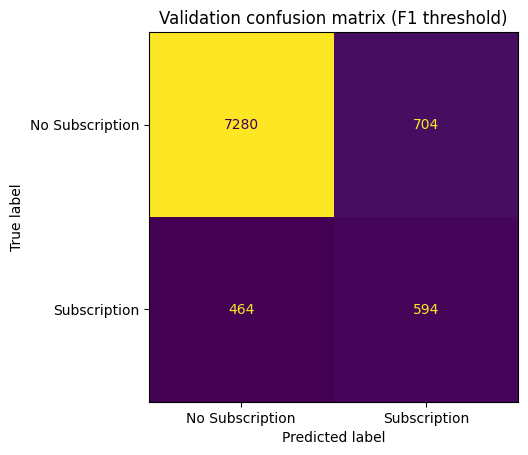

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    tuned_val_pred,
    display_labels=["No Subscription", "Subscription"],
    colorbar=False,
)
plt.title("Validation confusion matrix (F1 threshold)")
plt.show()


## Final model on train + validation

Refit tuned XGBoost on train+val and save artifacts for evaluation.


In [13]:
X_final = np.vstack([X_train, X_val])
y_final = np.concatenate([y_train, y_val])

final_params = dict(xgb_search.best_params_)
final_model = XGBClassifier(
    **final_params,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_model.fit(X_final, y_final)

# Held-out test snapshot
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)
sanity = {
    "Model": "Final Tuned XGBoost",
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "PR-AUC": average_precision_score(y_test, test_prob),
}
pd.DataFrame([sanity]).round(3)


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Final Tuned XGBoost,0.629,0.873,0.463,0.535,0.496,0.807,0.468


## Save model artifacts


In [14]:
OUT_DIR = Path("../data/processed")
joblib.dump(final_model, OUT_DIR / "final_model.joblib")
joblib.dump(
    {
        "threshold": best_threshold,
        "threshold_rule": "max_f1_on_validation",
        "best_params": final_params,
        "scale_pos_weight": scale_pos_weight,
    },
    OUT_DIR / "final_model_meta.joblib",
)
print("Saved final_model.joblib and final_model_meta.joblib")


Saved final_model.joblib and final_model_meta.joblib


## Summary

- Compared logistic regression, random forest, and XGBoost with stratified CV and imbalance-aware metrics
- Chose XGBoost for stronger ranking (ROC/PR-AUC), using `scale_pos_weight` for class imbalance
- Tuned on PR-AUC and selected an F1-maximizing validation threshold
- Refit on train+validation and saved the final model artifacts
